In [ ]:
# Scenario Question 💼
# A telecommunications company has collected data on 500 customers, including their monthly bill
# amount, average call duration, internet usage, and number of support calls. The company wants
# to group customers into meaningful segments to design targeted marketing campaigns and improve customer
#  service.
# You are tasked with:
# - Using K‑Means clustering to explore possible customer segments.
# - Applying the Elbow Method to determine where adding more clusters stops giving significant improvement.
# - Using the Silhouette Score to validate which number of clusters produces the most well‑separated
# and meaningful groups.

#step 1: import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

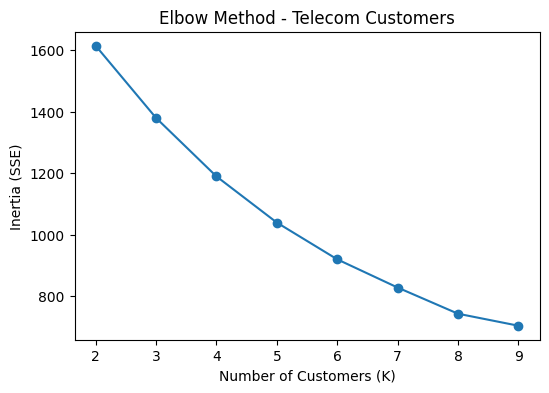

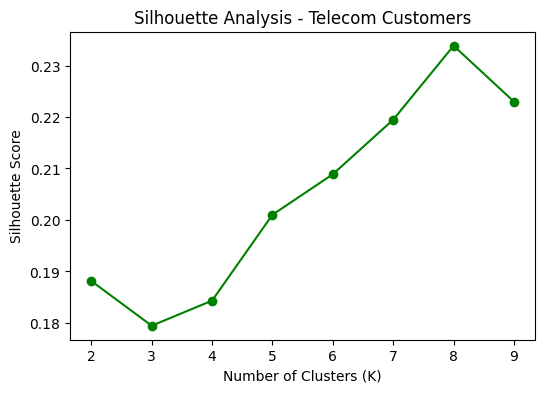

Best K based on silhouette score: 8


In [ ]:
# Step 2: Create synthetic telecom customer dataset
# (in practice, replace with actual enterprise customer data)
data = {
    'CustomerID': range(1, 501),
    'MonthlyBill': np.random.randint(20, 200, 500),       # monthly bill in $
    'CallDuration': np.random.randint(50, 500, 500),      # avg monthly call minutes
    'InternetUsage': np.random.randint(10, 300, 500),     # GB per month
    'SupportCalls': np.random.randint(0, 10, 500)         # number of support calls
}
df = pd.DataFrame(data)

#step 3: select features
x = df[['MonthlyBill', 'CallDuration', 'InternetUsage', 'SupportCalls']]

#step 4: Scale Features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#step 5: Elbow method
inertia = []
K_range = range(2, 10)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method - Telecom Customers')
plt.xlabel('Number of Customers (K)')
plt.ylabel('Inertia (SSE)')
plt.show()

#step 6: Silhouette Score
silhouette_scores = []
for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(x_scaled)
  score = silhouette_score(x_scaled, labels)
  silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Analysis - Telecom Customers')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

#step 7: Print best K suggestion
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K based on silhouette score: {best_k}")



